# Отток клиентов банка. Задача бинарной классификации


---


Версия v0.1.0

# ***Table Of Content***

#### Исходные данные:

датасет взят с kaggle:
https://www.kaggle.com/code/aspillai/bank-churn-dataset-classification-lightgbm/input
Датасет содержит инф о клиентах банка.

#### Постановка задачи

> <span style="color:cornflowerblue">🛈 Обучить модель для
> предсказания останется ли пользователь клиентом банка или нет.
> ♦ Сравнить результаты обучения разных моделей.
> ♦ Рассчитать метрики качества модели.
> ♦ Предоставить итоговые выводы. </span>

---


- формат для загрузки =csv
- Столбцы в датасете:
[id, CustomerId, Surname, CreditScore, Geography, Gender, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Exited]
- Целевой столбец = **exited**
- Количество строк > 165 000


Примеры значений:
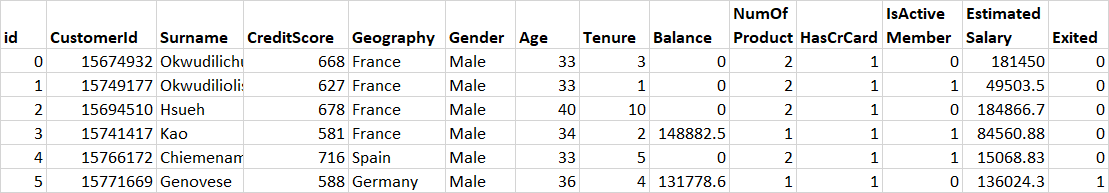

---
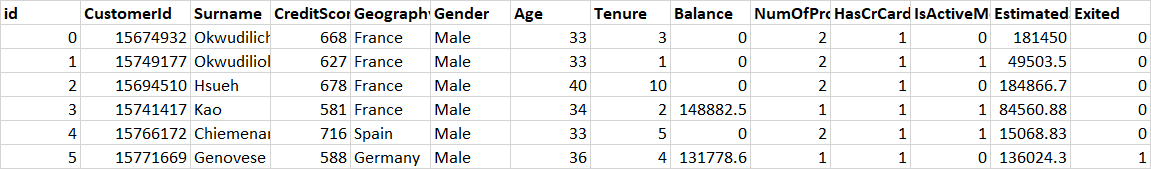

## Расшифровка столбцов

- id: порядковый номер записи(строки) в датасете. Никак не влияет на логику. Исключаю из обработки
- CustomerId: айди пользователя в системе банка. Тоже не должно никак влиять на итог. Исключаю из обработки
- Surname: фамилия пользователя. Пока не понятно надо ли это. Попробую включить в обработку
- CreditScore: кредитный рейтинг. Включаю в обработку
- Geography: видимо гражданство или место проживания пользователя. (К сожалению нет инф где находится сам банк или его филиалы). Включаю в обработку
- Gender: пол пользователя. Включаю в обработку
- Age: возраст, в годах. Включаю в обработку
- Tenure: сколько **лет** пользователь уже клиент банка. Включаю в обработку
- Balance: тут не понятно какой именно баланс (средний, текущий ..) на счетах банка. Включаю в обработку
- NumOfProducts: видимо количество продуктов банка в использовании. Включаю в обработку
- HasCrCard: видимо имеет действующую кредитную карту (посмотреть связи с балансом и с кредитным рейтингом). Включаю в обработку
- IsActiveMember: является активным пользователем (не очень понятен контекст значения). Включаю в обработку
- EstimatedSalary: расчетная зарплата(доход), видимо за год. Включаю в обработку
- Exited: пользователь перестал быть клиентом банка. Целевой столбец для предсказания. Включаю в обработку

---

## Раздел 1. Исследование исходных данных

---

In [60]:
# импорт всех библиотек в одном блоке кода
import pandas as pd
import numpy as np
import time
from datetime import datetime, timezone, timedelta

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns


import matplotlib
from statistics import correlation
from scipy import stats


model_version = '0.2.1'


In [61]:
# переменные для экспериментов  с данными
scalers = {
    'standardScaler': StandardScaler(),
    'minmaxScaler': MinMaxScaler(),
    'robustScaler': RobustScaler()
}

# логгирование результатов обучения моделей
def save_results_to_csv(model_name, scaler_name, accuracy, recall, precision, f1, train_time, filename='ml_logs.csv'):

    # set time offset (UTC+3)
    TZ_OFFSET = timedelta(hours=3)
    tz = timezone(TZ_OFFSET)
    current_time = datetime.now(tz).isoformat(timespec='seconds')
    print(f'current time is: {current_time}')

    # experiment result dict
    result = {
        'date_time': current_time,
        'model_name': model_name,
        'scaler': scaler_name,
        'accuracy': round(accuracy, 4),
        'recall': round(recall, 4),
        'precision': round(precision, 4),
        'f1_score': round(f1, 4),
        'train_time_seconds': round(train_time, 4),
        'model_version': model_version
    }

    # result dict to dataframe
    df_result = pd.DataFrame([result])

    # experiment log to CSV
    try:
        existing_csv = pd.read_csv(filename)
        df_result.to_csv(filename, mode='a', header=False, index=False)
        print(f'result logged to {filename}')
    except FileNotFoundError:
        df_result.to_csv(filename, mode='w', header=True, index=False)
        print(f'file created: {filename}')

### Раздел 1.1 Загрузка исходных данных

In [62]:
df_raw = pd.read_csv('datasets/bank_churn_raw.csv')


In [63]:
print(f'total rows, columns: {df_raw.shape}')
df_raw.head()

total rows, columns: (165034, 14)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1,0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1,1,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1,0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1,1,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1,1,15068.83,0


---

### Раздел 1.2 Проверка пропусков и дубликатов

In [64]:
# check gaps in the columns
df_raw.isnull().sum()

null_amount = df_raw.isnull().sum()

if null_amount.sum() == 0:
    print('data gaps in cells - NO')
else:
    columns_with_null = null_amount[null_amount > 0].to_dict()
    print(columns_with_null)

data gaps in cells - NO


In [65]:
# duplicate check
duplicate_count = df_raw.duplicated().sum()
print(f"entire row duplicates: {duplicate_count}")

if duplicate_count > 0:
    duplicate_rows = df_raw[df_raw.duplicated()]
    print(duplicate_rows)
    print('-'*15)

# check duplicates in id and CustomerId)
for column in ['id']:
    duplicates = df_raw.duplicated(subset=[column], keep=False)
    duplicate_count = duplicates.sum()

    if duplicate_count > 0:
        dup_indices = df_raw[duplicates].index.tolist()
        print(f'Column "{column}" contains: "{duplicate_count}" duplicates')
        print(f'duplicated row index: {dup_indices}')

        dup_values = df_raw[duplicates][column].tolist()
        print(f'duplicated values: {dup_values}\n')
    else:
        print(f'Duplicates in the column: "{column}" - NO\n')



entire row duplicates: 0
Duplicates in the column: "id" - NO



In [66]:
# separate code block because found many dupl. in the column
for column in ['CustomerId']:
    duplicates = df_raw.duplicated(subset=[column], keep=False)
    duplicate_count = duplicates.sum()

    if duplicate_count > 0:
        dup_indices = df_raw[duplicates].index.tolist()
        print(f'Column "{column}" contains: "{duplicate_count}" duplicates')
        print(f'duplicate indexes: {dup_indices}')

        dup_values = df_raw[duplicates][column].tolist()
        print(f' duplicate values: {dup_values}\n')
    else:
        print(f' Column "{column}" duplicates - NO\n')

Column "CustomerId" contains: "155733" duplicates
duplicate indexes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 153, 154, 156, 157, 158, 159, 160, 161, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 21

---
Столбец CustomerId ^ содержит повторы айдишек, хотя значения в других столбцах отличаются. Чего быть в принципе не должно. Убираю этот столбец из обработки т.к. айди пользователя не влияет на логику решений.

---

In [67]:
# new filtered dataframe
# Столбец с фамилией пока тоже убираю, т.к. не должно влиять и не понятно чего с ним делать

COLUMNS_DROP = ['id', 'CustomerId', 'Surname']
df_filtered = df_raw.drop(columns=COLUMNS_DROP).copy()
print(f'total rows, columns: {df_filtered.shape}')
df_filtered.head()


total rows, columns: (165034, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,668,France,Male,33.0,3,0.00,2,1,0,181449.97,0
1,627,France,Male,33.0,1,0.00,2,1,1,49503.50,0
2,678,France,Male,40.0,10,0.00,2,1,0,184866.69,0
3,581,France,Male,34.0,2,148882.54,1,1,1,84560.88,0
4,716,Spain,Male,33.0,5,0.00,2,1,1,15068.83,0


In [68]:
# df_filtered.describe(include='all')
df_filtered.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,668,France,Male,33.0,3,0.00,2,1,0,181449.97,0
1,627,France,Male,33.0,1,0.00,2,1,1,49503.50,0
2,678,France,Male,40.0,10,0.00,2,1,0,184866.69,0
3,581,France,Male,34.0,2,148882.54,1,1,1,84560.88,0
4,716,Spain,Male,33.0,5,0.00,2,1,1,15068.83,0


---
---

## Раздел 2. Подготовка данных
Столбцы 'Geography', 'Gender' надо преобразовать в цифровой вид.
Потом нормализовать все столбцы в один масштаб данных

### Раздел 2.1 Текстовые значение в цифровые

In [69]:
# статистика по столбцам для преобразования в категории. Количество значений и процент от общего объема



def column_stats_table(column_name):
    counts = df_filtered[column_name].value_counts()
    percentages = df_filtered[column_name].value_counts(normalize=True) * 100

    column_stats = pd.DataFrame({
        'value': counts.index,
        'count': counts.values,
        'percentage': percentages.values
    })

    return column_stats

# Column Geography
df_filtered.head()
# column_stats_table('Geography')

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,668,France,Male,33.0,3,0.00,2,1,0,181449.97,0
1,627,France,Male,33.0,1,0.00,2,1,1,49503.50,0
2,678,France,Male,40.0,10,0.00,2,1,0,184866.69,0
3,581,France,Male,34.0,2,148882.54,1,1,1,84560.88,0
4,716,Spain,Male,33.0,5,0.00,2,1,1,15068.83,0


In [70]:
# статистика по столбцам для преобразования в категории. Количество значений и процент от общего объема


def column_stats_table(column_name):
    counts = df_filtered[column_name].value_counts()
    percentages = df_filtered[column_name].value_counts(normalize=True) * 100

    column_stats = pd.DataFrame({
        'value': counts.index,
        'count': counts.values,
        'percentage': percentages.values
    })

    return column_stats

df_filtered.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,668,France,Male,33.0,3,0.00,2,1,0,181449.97,0
1,627,France,Male,33.0,1,0.00,2,1,1,49503.50,0
2,678,France,Male,40.0,10,0.00,2,1,0,184866.69,0
3,581,France,Male,34.0,2,148882.54,1,1,1,84560.88,0
4,716,Spain,Male,33.0,5,0.00,2,1,1,15068.83,0


In [71]:
# Столбец Geography в формат категорий
# уточнить как это правильно делается, надо ли учитывать частоту значений ..

# df_filtered['Geography'] = pd.Categorical(df_filtered['Geography'])
# print(f'тип данных в столбце: {df_filtered['Geography'].dtype}')
#
# geography_coded_values = sorted(df_filtered['Geography'].unique())
# geography_dict = {value: idx for idx, value in enumerate(geography_coded_values)}
# print(geography_dict)
#print(df_filtered['Geography'].cat.codes)

---

In [72]:
# Столбец Gender

column_stats_table('Geography')


,value,count,percentage
0,France,94215,57.088236
1,Spain,36213,21.942751
2,Germany,34606,20.969012


In [73]:
column_stats_table('Gender')

,value,count,percentage
0,Male,93150,56.442915
1,Female,71884,43.557085


In [74]:
# Столбец Gender в формат категорий

# df_filtered['Gender'] = pd.Categorical(df_filtered['Gender'])
# print(f'тип данных в столбце: {df_filtered['Gender'].dtype}')
#
# gender_coded_values = sorted(df_filtered['Gender'].unique())
# gender_dict = {value: idx for idx, value in enumerate(gender_coded_values)}
# print(gender_dict)


df_filtered.corr() не работает с категоризованными столбцами через пандас.  надо все-таки явно заменить значения на цифры

LabelEncoder() из sklearn.preprocessing работает норм

In [75]:
# кодирование значений в цифры по столбцу Geography

if 'Geo_encoded' in df_filtered.columns:
    df_filtered.drop(columns=['Geo_encoded'], inplace=True)

geo_encoded = LabelEncoder()
idx = df_filtered.columns.get_loc('Geography')
df_filtered.insert(idx + 1, 'Geo_encoded', geo_encoded.fit_transform(df_filtered['Geography']))

df_filtered.head()

,CreditScore,Geography,Geo_encoded,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,668,France,0,Male,33.0,3,0.00,2,1,0,181449.97,0
1,627,France,0,Male,33.0,1,0.00,2,1,1,49503.50,0
2,678,France,0,Male,40.0,10,0.00,2,1,0,184866.69,0
3,581,France,0,Male,34.0,2,148882.54,1,1,1,84560.88,0
4,716,Spain,2,Male,33.0,5,0.00,2,1,1,15068.83,0


In [76]:
# кодирование значений в цифры по столбцу Gender

if 'Gender_encoded' in df_filtered.columns:
    df_filtered.drop(columns=['Gender_encoded'], inplace=True)

gender_encoded = LabelEncoder()

idx = df_filtered.columns.get_loc('Gender')
df_filtered.insert(idx + 1, 'Gender_encoded', gender_encoded.fit_transform(df_filtered['Gender']))

df_filtered.head()

,CreditScore,Geography,Geo_encoded,Gender,Gender_encoded,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,668,France,0,Male,1,33.0,3,0.00,2,1,0,181449.97,0
1,627,France,0,Male,1,33.0,1,0.00,2,1,1,49503.50,0
2,678,France,0,Male,1,40.0,10,0.00,2,1,0,184866.69,0
3,581,France,0,Male,1,34.0,2,148882.54,1,1,1,84560.88,0
4,716,Spain,2,Male,1,33.0,5,0.00,2,1,1,15068.83,0


In [77]:
# теперь дроп текстовых версий колонок гео и гендер
df_filtered.drop(columns = ['Geography', 'Gender'], inplace=True)

# и теперь проверка корреляции
df_filtered.corr()

,CreditScore,Geo_encoded,Gender_encoded,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,1.000000,0.005379,0.002310,-0.008918,0.000942,0.006973,0.011361,-0.002828,0.014790,-0.001820,-0.027383
Geo_encoded,0.005379,1.000000,-0.012092,0.034110,0.000276,0.134642,-0.025123,-0.016715,-0.003493,-0.004102,0.053343
Gender_encoded,0.002310,-0.012092,1.000000,-0.063139,0.008767,-0.014699,0.026098,0.006418,0.033722,-0.007778,-0.146442
Age,-0.008918,0.034110,-0.063139,1.000000,-0.010830,0.064318,-0.102195,-0.012111,0.003320,-0.005399,0.340768
Tenure,0.000942,0.000276,0.008767,-0.010830,1.000000,-0.009481,0.007335,0.005327,-0.005532,0.000971,-0.019565
Balance,0.006973,0.134642,-0.014699,0.064318,-0.009481,1.000000,-0.361033,-0.018584,-0.015073,0.008586,0.129743
NumOfProducts,0.011361,-0.025123,0.026098,-0.102195,0.007335,-0.361033,1.000000,0.005482,0.039736,-0.004285,-0.214554
HasCrCard,-0.002828,-0.016715,0.006418,-0.012111,0.005327,-0.018584,0.005482,1.000000,-0.021034,0.004438,-0.022141
IsActiveMember,0.014790,-0.003493,0.033722,0.003320,-0.005532,-0.015073,0.039736,-0.021034,1.000000,-0.008080,-0.210237
EstimatedSalary,-0.001820,-0.004102,-0.007778,-0.005399,0.000971,0.008586,-0.004285,0.004438,-0.008080,1.000000,0.018827


---
## Раздел 2. Нормализация данных по столбцам

In [78]:
# нормализовать столбцы с числовыми значениями, кроме столбцов с [0,1]
# сейчас метод нормализации minmax из sklearn
# надо будет перебрать несколько способов

def normalize_columns(df_to_normal):
    cols_to_norm = [col for col in df_to_normal.select_dtypes(include=['int64', 'float64']).columns
                    if not set(df_to_normal[col].unique()).issubset({0, 1})]
    binary_cols = [col for col in df_to_normal.select_dtypes(include=['int64', 'float64']).columns
                   if set(df_to_normal[col].unique()).issubset({0, 1})]

    df_norm = df_to_normal[cols_to_norm].copy()
    if cols_to_norm:
        df_norm[cols_to_norm] = MinMaxScaler().fit_transform(df_norm[cols_to_norm])
    if binary_cols:
        df_norm = pd.concat([df_norm, df_to_normal[binary_cols]], axis=1)

    print(f'normalized columns: {cols_to_norm} \nbinary columns as is: {binary_cols}')
    print('-'*15)
    return df_norm


df_normalized = normalize_columns(df_filtered)
print('\n', df_normalized.head())

normalized columns: ['CreditScore', 'Geo_encoded', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary'] 
binary columns as is: ['Gender_encoded', 'HasCrCard', 'IsActiveMember', 'Exited']
---------------

    CreditScore  Geo_encoded       Age  Tenure   Balance  NumOfProducts  \
0        0.636          0.0  0.202703     0.3  0.000000       0.333333   
1        0.554          0.0  0.202703     0.1  0.000000       0.333333   
2        0.656          0.0  0.297297     1.0  0.000000       0.333333   
3        0.462          0.0  0.216216     0.2  0.593398       0.000000   
4        0.732          1.0  0.202703     0.5  0.000000       0.333333   

   EstimatedSalary  Gender_encoded  HasCrCard  IsActiveMember  Exited  
0         0.907279               1          1               0       0  
1         0.247483               1          1               1       0  
2         0.924364               1          1               0       0  
3         0.422787               1          1      

---
## Раздел 3. Подготовка к обучению

проверим соотношение значений в целевом столбце

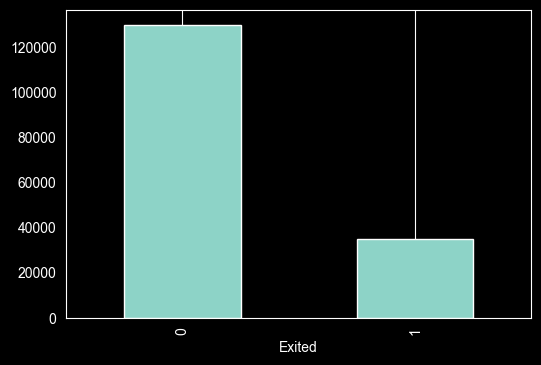

In [79]:
df_normalized['Exited'].value_counts().plot.bar(figsize=(6, 4))
plt.grid(axis='y')

понял, что надо использовать stratify для сохранения соотношения в тренировочных блоках
? а о чем еще нужно подумать при таком соотношении ?

следующий шаг: проверить распределения значений по всем колонкам в датасете

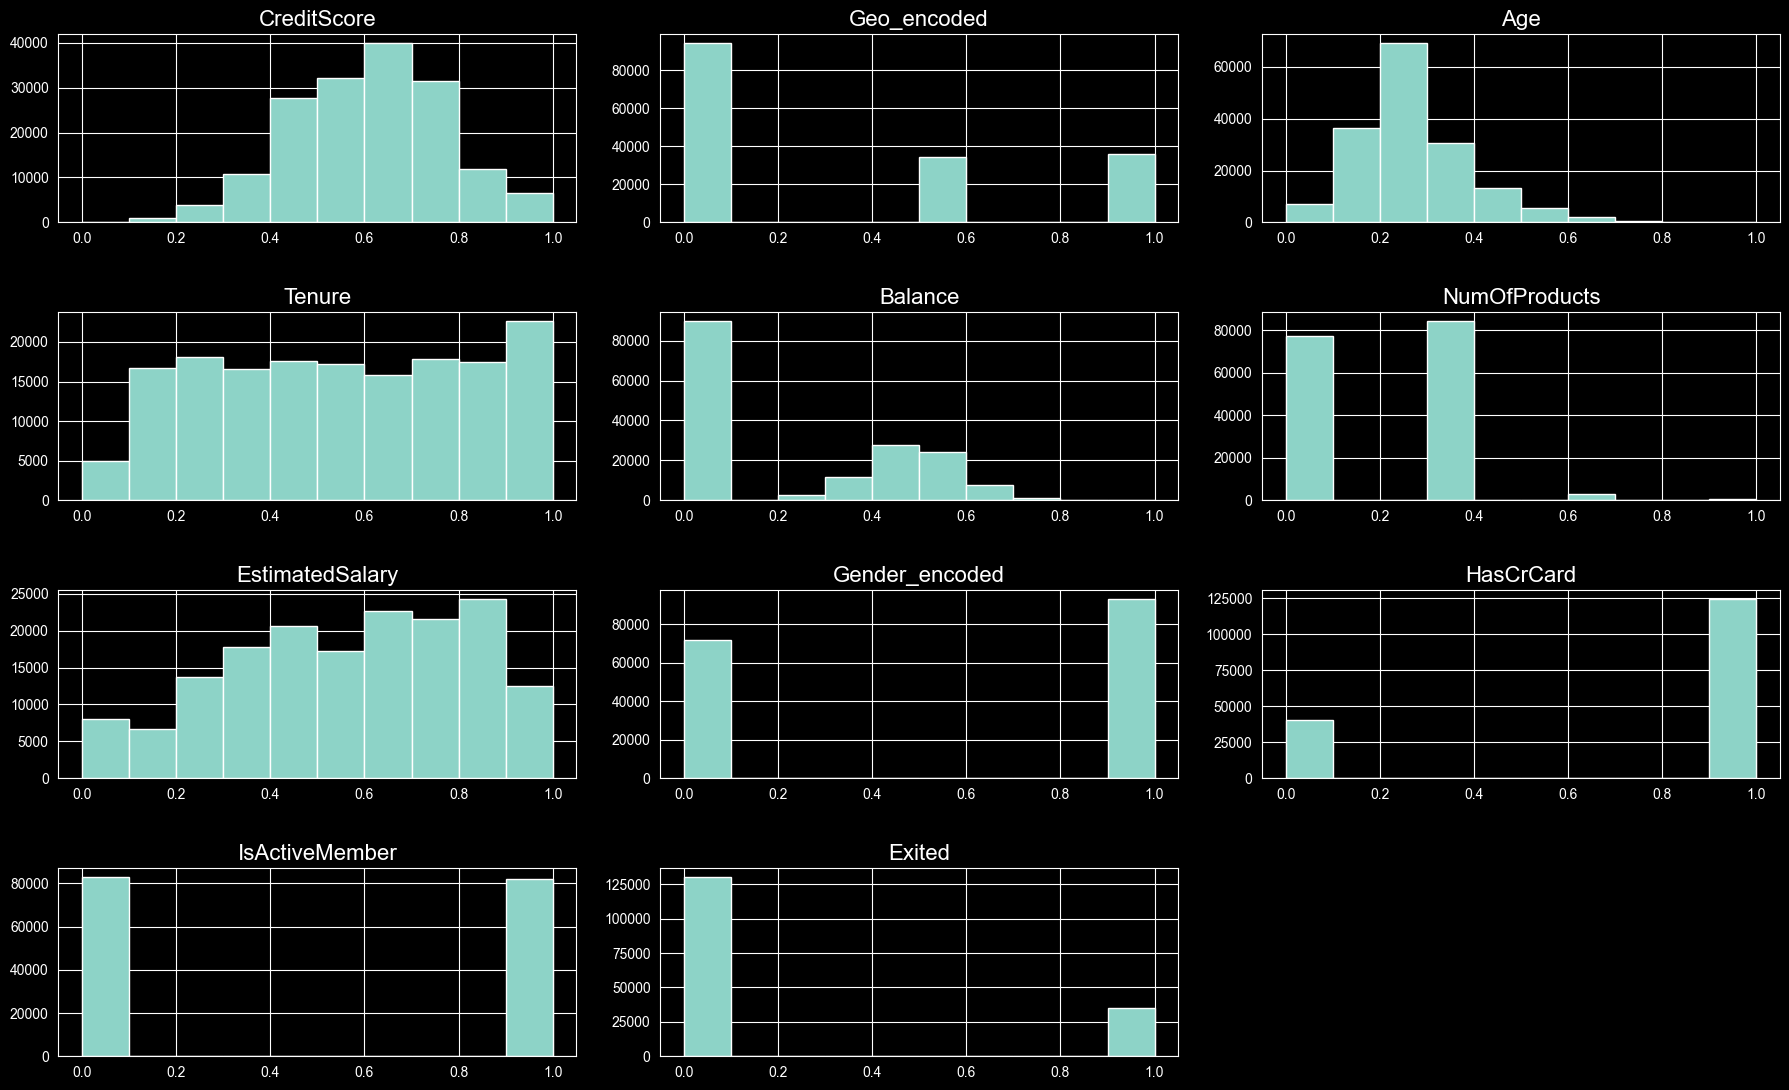

In [80]:

plt.rc('axes', titlesize=16)
df_normalized.hist(figsize=(18, 11), xlabelsize=10, ylabelsize=10)
plt.tight_layout(h_pad=3.0, w_pad=2.0)
# тут надо бы еще добавить абсолютные мин/макс значения (до нормализации)

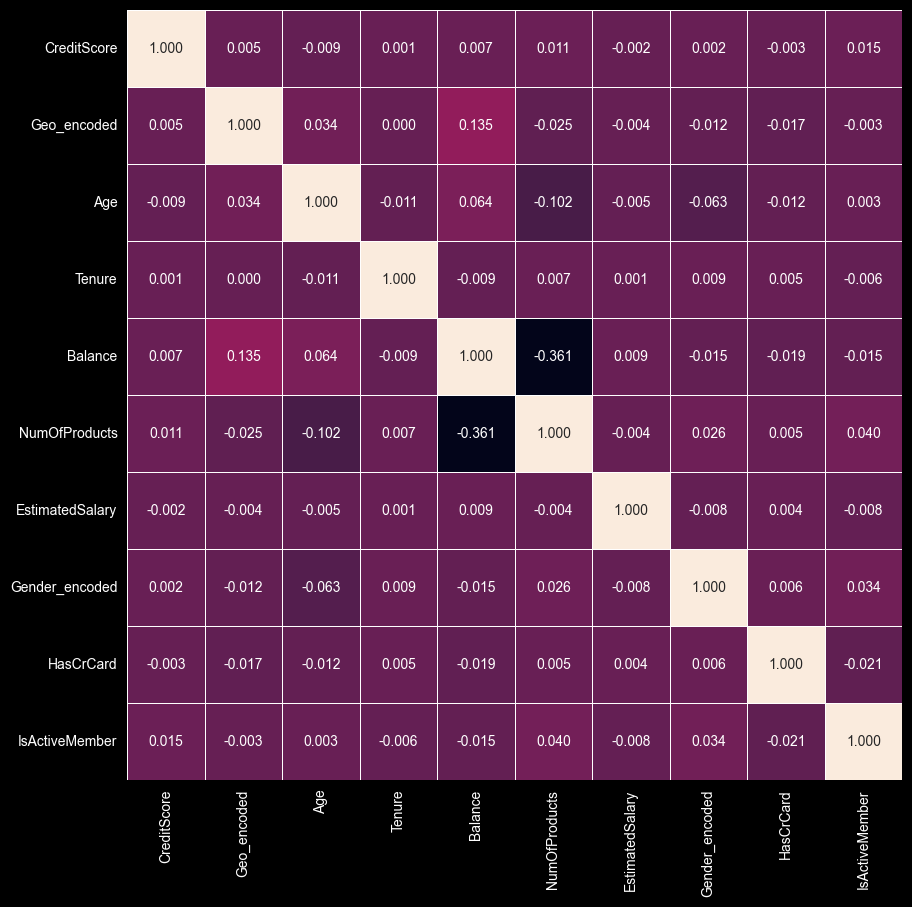

In [81]:
# еще раз корреляция между столбцами (без целевого) в виде тепловой карты

plt.figure(figsize=(10, 10))
sns.heatmap(df_normalized.drop(['Exited'], axis=1).corr(), annot=True, cbar=False, linewidths=.5, fmt= '.3f')
plt.show()

максимальное значение - |0.361| вроде можем пренебречь и идти дальше

In [82]:
# df_normalized.head()

X = df_normalized.drop(['Exited'],axis=1)
Y = df_normalized['Exited']

print(f'Features shape: {X.shape}')
print(f'Target shape: {Y.shape}')

# Cross validation setup
cv = StratifiedKFold(n_splits=7, shuffle=True, random_state=555)


Features shape: (165034, 10)
Target shape: (165034,)


---

### TO-DO
- вставить в раздел 2: проверить выбросы в значениях
- проверить разные скейлеры - мин/макс, стандарт ..
- само обучение
- проверка точности, качества

In [83]:
# training logic automation
def train_model_with_scalers(model, model_base_name, X_data, Y_data, cv_strategy):

    results_list = []

    for scaler_name, scaler in scalers.items():
        print(f'\n{"-"*15}')
        print(f'Training {model_base_name} with {scaler_name}')
        print(f'\n{"-"*15}')

        # normalize numeric columns
        X_scaled = scaler.fit_transform(X_data)

        # Create model copy
        model_copy = model.__class__(**model.get_params())

        # Track time and train
        start_time = time.time()

        # Perform cross-validation
        accuracy_scores = cross_val_score(model_copy, X_scaled, Y_data, cv=cv_strategy, scoring='accuracy')
        recall_scores = cross_val_score(model_copy, X_scaled, Y_data, cv=cv_strategy, scoring='recall')
        precision_scores = cross_val_score(model_copy, X_scaled, Y_data, cv=cv_strategy, scoring='precision')
        f1_scores = cross_val_score(model_copy, X_scaled, Y_data, cv=cv_strategy, scoring='f1')

        train_time = time.time() - start_time

        # Calculate mean metrics
        mean_accuracy = accuracy_scores.mean()
        mean_recall = recall_scores.mean()
        mean_precision = precision_scores.mean()
        mean_f1 = f1_scores.mean()

        # Display results
        print(f'Train time: {train_time:.4f} seconds')
        print(f'Accuracy: {mean_accuracy:.4f} (+/- {accuracy_scores.std() * 2:.4f})')
        print(f'Recall: {mean_recall:.4f}')
        print(f'Precision: {mean_precision:.4f}')
        print(f'F1-Score: {mean_f1:.4f}')

        # Save to CSV
        save_results_to_csv(
            model_name=f'{model_base_name}',
            scaler_name=scaler_name,
            accuracy=mean_accuracy,
            recall=mean_recall,
            precision=mean_precision,
            f1=mean_f1,
            train_time=train_time
        )

        results_list.append({
            'scaler': scaler_name,
            'accuracy': mean_accuracy,
            'recall': mean_recall,
            'precision': mean_precision,
            'f1': mean_f1,
            'train_time': train_time
        })

    return results_list

In [84]:
print(f'\n{"-"*15}')
print('Logistic regression with different scalers')
print(f'\n{"-"*15}')

logreg = LogisticRegression(max_iter=1000, random_state=555)
logreg_results = train_model_with_scalers(logreg, 'LogisticRegression', X, Y, cv)


---------------
Logistic regression with different scalers

---------------

---------------
Training LogisticRegression with standardScaler

---------------
Train time: 2.3410 seconds
Accuracy: 0.8260 (+/- 0.0017)
Recall: 0.3447
Precision: 0.6734
F1-Score: 0.4560
current time is: 2026-05-30T22:53:45+03:00
file created: ml_logs.csv

---------------
Training LogisticRegression with minmaxScaler

---------------
Train time: 7.6458 seconds
Accuracy: 0.8260 (+/- 0.0017)
Recall: 0.3442
Precision: 0.6738
F1-Score: 0.4556
current time is: 2026-05-30T22:53:53+03:00
result logged to ml_logs.csv

---------------
Training LogisticRegression with robustScaler

---------------
Train time: 3.4396 seconds
Accuracy: 0.8260 (+/- 0.0017)
Recall: 0.3447
Precision: 0.6734
F1-Score: 0.4559
current time is: 2026-05-30T22:53:56+03:00
result logged to ml_logs.csv
